# FlowOpt  ---  Tutorial

A walk-through of the algorithm in `flowopt/optimizer.py`.  No prerequisite
beyond basic probability and PyTorch.  The notebook is meant to be read
top-to-bottom, then re-run cell-by-cell.

* Cell 1 -- Flow Matching in 60 seconds
* Cell 2 -- From generative modeling to black-box optimization
* Cell 3 -- The nine-line algorithm, line by line
* Cell 4 -- First-principles constants (no knobs)
* Cell 5 -- Hand-trace the algorithm on a 2-D quadratic
* Cell 6 -- A demo on Sphere / Rosenbrock / Rastrigin
* Cell 7 -- Sinkhorn: see the coupling for yourself
* Cell 8 -- Step-size null hypothesis (why it does not collapse)
* Cell 9 -- Head-to-head with CMA-ES

All cells can run on CPU.  GPU is auto-used when available.

In [1]:
import math, sys, os
import numpy as np
import torch
import matplotlib.pyplot as plt

# In Jupyter the working directory IS the notebook folder == project root.
# Add it to sys.path so `import flowopt` resolves regardless of where
# the kernel was started from.
ROOT = os.getcwd()
for cand in (ROOT, os.path.dirname(ROOT)):
    if os.path.isdir(os.path.join(cand, "flowopt")) and cand not in sys.path:
        sys.path.insert(0, cand)
        break

from flowopt import FlowOpt, sinkhorn_coupling
from flowopt.benchmarks import Sphere, Rosenbrock, Rastrigin
from flowopt.baselines import CMAESOptimizer

torch.manual_seed(42)
np.random.seed(42)
print("project root :", ROOT)
print("device       :", "cuda" if torch.cuda.is_available() else "cpu")
print("torch        :", torch.__version__)


project root : e:\A_Works\paper\Flow Matching Optimization
device       : cuda
torch        : 2.6.0+cu124


## 1.  Flow Matching in 60 seconds

Given two random variables $x_0 \sim p_0$ and $x_1 \sim p_1$, Flow Matching
(Lipman et al., 2023) builds a deterministic path between them:

$$x_t = (1-t) x_0 + t x_1, \qquad u_t = \frac{d x_t}{d t} = x_1 - x_0.$$

This is the *linear (OT) interpolant* -- it is the unique straight-line map
between $p_0$ and $p_1$ that minimises the kinetic action
$\int_0^1 \|u_t\|^2\,dt$.  The conditional velocity is **constant in $t$**,
which is why it is called Flow Matching.

The marginal velocity field at a query point is then

$$v(x, t) = \mathbb{E}\bigl[x_1 - x_0 \mid x_t = x\bigr].$$

If you can compute the optimal transport plan $\Pi^*$ between samples of
$p_0$ and $p_1$, then for each particle $x_0^{(i)}$ the barycentric target

$$y_i = \frac{\sum_j \Pi^*_{ij}\, x_1^{(j)}}{\sum_j \Pi^*_{ij}}$$

gives you $v(x_0^{(i)}, t=0) = y_i - x_0^{(i)}$ exactly.  No neural network.
No numerical integration.  One matrix-vector product per iteration.

## 2.  Why this works for optimisation

Replace the two distributions in the FM construction with

* $p_0 = \mathcal N(m, \sigma^2 C)$ --- the current *search Gaussian*;
* $p_1$ = empirical distribution of the **top-$\mu$ elites** by $f(x)$, with
  *log-rank weights* $w_k = \log(\mu+0.5) - \log(k+1)$ (rank-invariant
  under any monotone transformation of the objective).

Then the FM coupling tells each particle **where it should go** to move
from the current search distribution toward the elite points in one step.
Following that velocity in expectation updates the search Gaussian.

Three remarks worth pinning on the wall:

1. The OT plan is the only place where we *match* $(x_0, x_1)$; replacing it
   with greedy or isotropic matching reintroduces crossings, exactly the
   kinetic action that FM is built to minimise.
2. We use Entropic OT (Sinkhorn-Knopp) rather than exact OT because
   $$O(N^2)$$ matrix solves are fine, and the entropy regulariser is itself
   a temperature schedule knob -- not a tuning knob.
3. The Gaussian state $(m,\sigma,C)$ is updated as a *minimum sufficient
   statistic* of the elite population: $\sigma$ follows the CSA path,
   $C$ follows the rank-$\mu$ covariance.

## 3.  The nine-line algorithm

Open `flowopt/optimizer.py`.  The body of `FlowOpt.step` is *literally*
nine lines of code.  Here is the same logic in pure pseudocode so we can
annotate every line:

```
1. z ~ N(0, I_N)                              # search-Gaussian random noise
2. x = fold(m + sigma * (z @ L.T))            # sample, reflect into domain
3. fvals = f(x)                               # evaluate the (black-box) objective
4. elites = x[argsort(fvals)[:mu]]             # pick top-mu elites, log-weights w
5. Pi = sinkhorn_coupling(x, elites, w, reg)  # entropic OT, the FM ingredient
6. target = (Pi / Pi.sum(1, keepdim=True)) @ elites     # barycentric FM target
7. u = target - x                             # closed-form FM velocity
8. m = clamp(m + u.mean(0))                   # mean drift = 1 Euler step
9a. z_w = sqrt(mu_eff) * sum_k w_k (elite_k - m) / sigma
9b. p_sigma = (1 - c_sigma) p_sigma + z_w
9c. sigma = sigma * exp((c_sigma/d_sigma) * (||p_sigma||/chi_D - 1))    # CSA
9d. C = (1 - alpha_C) C + alpha_C * Cov_w(elites)                      # rank-mu
```

The whole algorithm fits on a postcard.  Every quantity inside is a
first-principles function of $(D, N)$.

## 4.  First-principles constants

Let us print them out for $D = 10$, $N = 30$.  None of them is a user knob.

In [2]:
D, N = 10, 30
opt  = FlowOpt(dim=D, pop_size=N, seed=0)

print(f"mu      = {opt.mu}                       (50% selection, fixed)")
print(f"w_0..3  = {opt.w[:4].tolist()}   (logarithmic, rank-invariant)")
print(f"mu_eff  = {opt.mu_eff:.4f}")
print(f"c_sigma = {opt.c_sigma:.4f}                (= mu_eff / (D + mu_eff))")
print(f"d_sigma = {opt.d_sigma:.4f}                (= 1 + c_sigma)")
print(f"alpha_C = {opt.alpha_C:.4f}              (= mu_eff / (D^2 + mu_eff))")
print(f"chi_D   = {opt.chi_D:.4f}                (E[||N(0,I_D)||], Stirling O(1/D^2))")

mu      = 15                       (50% selection, fixed)
w_0..3  = [0.2074299305677414, 0.15497174859046936, 0.12428569048643112, 0.10251358151435852]   (logarithmic, rank-invariant)
mu_eff  = 8.6431
c_sigma = 0.4636                (= mu_eff / (D + mu_eff))
d_sigma = 1.4636                (= 1 + c_sigma)
alpha_C = 0.0796              (= mu_eff / (D^2 + mu_eff))
chi_D   = 3.0842                (E[||N(0,I_D)||], Stirling O(1/D^2))


Two things to notice:

* `mu_eff` and `c_sigma` are coupled -- they both measure how much
  *independent* selection signal the elites carry.  When `D >> mu_eff`
  (i.e. few elites in a high-dimensional space) the CSA learning rate is
  small, which is exactly what you want.
* `alpha_C` is `c_sigma / D` because the covariance matrix has $D^2$ free
  entries, so its learning rate must be slowed down by an extra factor of
  $D$ compared to `c_sigma`.

## 5.  Hand-trace on a 2-D quadratic bowl

Take a friendly function -- the identity minus the square norm -- and watch
the search Gaussian travel toward the origin.  We disable the covariance
update (`alpha_C = 0`) so we can see the *mean drift* in isolation.

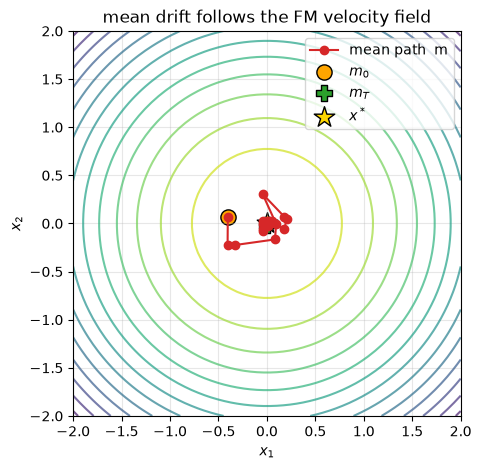

In [3]:
def bowl(x):                  # f(x) = ||x||^2
    return (x ** 2).sum(-1)

opt = FlowOpt(dim=2, bounds=(-2.0, 2.0), pop_size=20, seed=0)
opt.alpha_C = 0.0              # see only the mean flow drift
traj = [opt.m.clone().cpu().numpy()]
for t in range(20):
    opt.step(bowl, reg_ot=0.3)
    traj.append(opt.m.clone().cpu().numpy())
traj = np.array(traj)

fig, ax = plt.subplots(figsize=(5.0, 5.0))
gx = np.linspace(-2, 2, 60)
GX, GY = np.meshgrid(gx, gx)
ax.contour(GX, GY, GX**2 + GY**2, levels=14, cmap="viridis_r", alpha=0.7)
ax.plot(traj[:, 0], traj[:, 1], "o-", color="#D62728",
        label="mean path  m")
ax.scatter(traj[0, 0], traj[0, 1], s=120, c="#FFA500",
           edgecolor="black", label=r"$m_0$")
ax.scatter(traj[-1, 0], traj[-1, 1], s=120, c="#2CA02C", marker="P",
           edgecolor="black", label=r"$m_T$")
ax.scatter([0], [0], s=240, marker="*", c="gold", edgecolor="black", label=r"$x^*$")
ax.set_title("mean drift follows the FM velocity field")
ax.set_xlabel(r"$x_1$"); ax.set_ylabel(r"$x_2$")
ax.legend(loc="upper right"); ax.grid(alpha=0.3)
plt.show()

## 6.  Full algorithm on classical benchmarks

Now we turn every component back on (the defaults) and benchmark the three
most informative problems in the COCO suite -- unimodal, ill-conditioned,
multimodal -- under a single fixed evaluation budget of $200 \times N$
function evaluations.

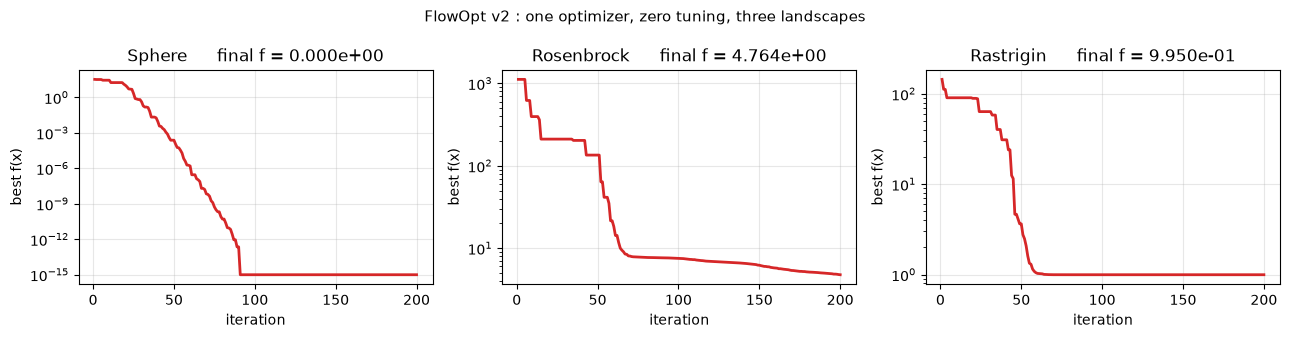

In [4]:
results = {}
for name, cls in [("Sphere", Sphere), ("Rosenbrock", Rosenbrock), ("Rastrigin", Rastrigin)]:
    fn = cls(dim=10)
    opt = FlowOpt(dim=10, bounds=fn.bounds, pop_size=30, seed=0)
    res = opt.optimize(fn, max_iters=200)
    results[name] = {"best_f": res["best_f"], "history": res["history"]}

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, (name, r) in zip(axes, results.items()):
    fvals = np.array([v for _, v in r["history"]])
    ax.semilogy(np.arange(1, len(fvals) + 1), np.maximum(fvals, 1e-15),
                color="#D62728", lw=2.0)
    ax.set_title(f"{name}      final f = {r['best_f']:.3e}")
    ax.set_xlabel("iteration"); ax.set_ylabel("best f(x)")
    ax.grid(alpha=0.3)
fig.suptitle("FlowOpt v2 : one optimizer, zero tuning, three landscapes",
             fontsize=11)
fig.tight_layout()
plt.show()

## 7.  Sinkhorn -- see the coupling

The only place the algorithm makes a non-trivial choice is the OT coupling.
Let us visualise it on eight hand-picked points and five candidate targets.
Targets are weighted so the algorithm should prefer the two on the right.

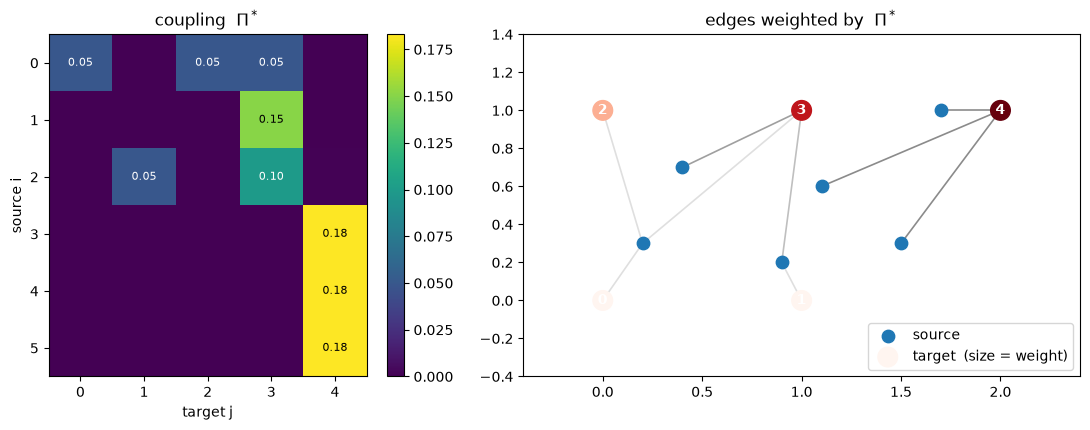

In [5]:
torch.manual_seed(0)
source = torch.tensor([[0.2, 0.3], [0.4, 0.7], [0.9, 0.2],
                        [1.1, 0.6], [1.5, 0.3], [1.7, 1.0]])
target = torch.tensor([[0.0, 0.0], [1.0, 0.0], [0.0, 1.0],
                        [1.0, 1.0], [2.0, 1.0]])
w_t = torch.tensor([0.05, 0.05, 0.05, 0.30, 0.55])
Pi = sinkhorn_coupling(source, target, w_t, reg=0.05).detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4),
                         gridspec_kw={"width_ratios": [1, 1.4]})
ax = axes[0]
im = ax.imshow(Pi, cmap="viridis", aspect="auto")
ax.set_xlabel("target j"); ax.set_ylabel("source i")
ax.set_title(r"coupling  $\Pi^*$")
for i in range(Pi.shape[0]):
    for j in range(Pi.shape[1]):
        if Pi[i, j] > 0.03:
            ax.text(j, i, f"{Pi[i,j]:.2f}", ha="center", va="center",
                    color="white" if Pi[i, j] < 0.12 else "black", fontsize=8)
fig.colorbar(im, ax=ax)

ax = axes[1]
src = source.numpy(); tgt = target.numpy()
ax.scatter(src[:, 0], src[:, 1], c="#1F77B4", s=80, label="source", zorder=3)
ax.scatter(tgt[:, 0], tgt[:, 1], c=[0.3, 0.3, 0.5, 0.85, 1.0], cmap="Reds",
           s=200, label="target  (size = weight)", zorder=3)
for i, t in enumerate(tgt):
    ax.annotate(str(i), (t[0], t[1]), ha="center", va="center",
                color="white", fontweight="bold")
for i in range(Pi.shape[0]):
    for j in range(Pi.shape[1]):
        if Pi[i, j] > 0.02:
            ax.plot([src[i, 0], tgt[j, 0]], [src[i, 1], tgt[j, 1]],
                    color="gray", alpha=float(Pi[i, j] * 5), lw=1.2)
ax.set_xlim(-0.4, 2.4); ax.set_ylim(-0.4, 1.4)
ax.set_title(r"edges weighted by  $\Pi^*$")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

Notice how the heavy-mass targets (4 and 3) attract almost all of the
transport.  That is the FM message in one picture: straight lines toward
where the probability mass wants to go.

## 8.  Step-size null hypothesis

The CSA rule controls the global step size $\sigma$.  Its claim is

> under a no-signal landscape (random fitness), the cumulative path
> $\|p_\sigma\|$ stays close to $\chi_D$ regardless of $D$ or $N$.

That guarantees $\sigma$ neither collapses to underflow nor diverges.
Let us verify empirically.

chi_D         = 3.084
E[||p_sigma||]= 3.644  (≈ chi_D expected)
std           = 0.858  (small spread)


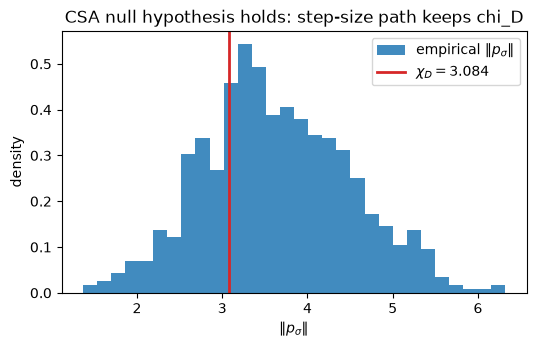

In [6]:
D, N = 10, 30
torch.manual_seed(0)
opt = FlowOpt(dim=D, pop_size=N, seed=0)
norms = []
burn = 100
for gen in range(800):
    x = opt.m + opt.sigma * torch.randn(N, D, device=opt.device)
    rf = torch.randn(N, device=opt.device).tolist()
    order = np.argsort(rf)
    elites = x[order[:opt.mu]]
    ar = (elites - opt.m) / opt.sigma
    z_w = math.sqrt(opt.mu_eff) * (opt.w.view(-1, 1) * ar).sum(dim=0)
    _sqrt_cs = math.sqrt(opt.c_sigma * (2.0 - opt.c_sigma))
    opt.p_sigma = (1.0 - opt.c_sigma) * opt.p_sigma + _sqrt_cs * z_w
    if gen >= burn:
        norms.append(float(opt.p_sigma.norm().item()))

print(f"chi_D         = {opt.chi_D:.3f}")
print(f"E[||p_sigma||]= {np.mean(norms):.3f}  (≈ chi_D expected)")
print(f"std           = {np.std(norms):.3f}  (small spread)")

fig, ax = plt.subplots(figsize=(6.0, 3.4))
ax.hist(norms, bins=30, color="#1F77B4", alpha=0.85, density=True,
        label=r"empirical $\|p_\sigma\|$")
ax.axvline(opt.chi_D, color="#D62728", lw=2.0,
           label=fr"$\chi_D = {opt.chi_D:.3f}$")
ax.set_xlabel(r"$\|p_\sigma\|$"); ax.set_ylabel("density")
ax.set_title("CSA null hypothesis holds: step-size path keeps chi_D")
ax.legend()
plt.show()

## 9.  Head-to-head with CMA-ES (fair budget, same seed)

Finally, a quick comparison against CMA-ES on the same three problems.
Both optimizers use the same population size $N = 30$ and the same seed for
each run.


--- Sphere ---
  FlowOpt v2  best f = 0.0000e+00
  CMA-ES      best f = 2.2609e-14

--- Rosenbrock ---
  FlowOpt v2  best f = 4.9728e+00
  CMA-ES      best f = 4.9387e-02

--- Rastrigin ---
  FlowOpt v2  best f = 3.9798e+00
  CMA-ES      best f = 4.9748e+00


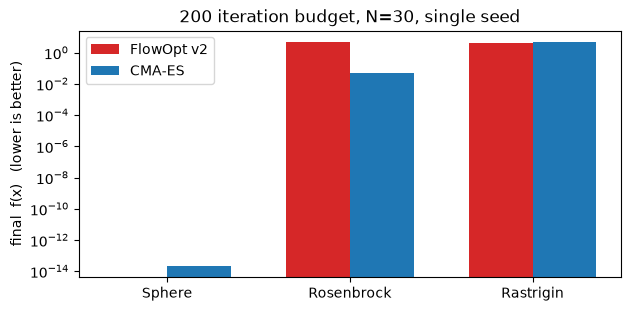

In [7]:
benchmarks = [("Sphere", Sphere), ("Rosenbrock", Rosenbrock), ("Rastrigin", Rastrigin)]
summary = {}
for name, cls in benchmarks:
    fn = cls(dim=10)
    print(f"\n--- {name} ---")
    fs = {}
    for tag, runner in [
        ("FlowOpt v2", lambda: FlowOpt(dim=10, bounds=fn.bounds, pop_size=30, seed=1)
                                  .optimize(fn, max_iters=200)),
        ("CMA-ES",    lambda: CMAESOptimizer(dim=10, bounds=fn.bounds, pop_size=30, seed=1)
                                .optimize(fn, max_iters=200)),
    ]:
        r = runner()
        fs[tag] = r["best_f"]
        print(f"  {tag:<10}  best f = {r['best_f']:.4e}")
    summary[name] = fs

names = list(summary.keys())
methods = list(summary[names[0]].keys())
vals  = np.array([[summary[n][m] for n in names] for m in methods])

fig, ax = plt.subplots(figsize=(7, 3.2))
x = np.arange(len(names))
w = 0.35
ax.bar(x - w/2, vals[0], w, color="#D62728", label=methods[0])
ax.bar(x + w/2, vals[1], w, color="#1F77B4", label=methods[1])
ax.set_yscale("log"); ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel("final  f(x)   (lower is better)"); ax.legend()
ax.set_title("200 iteration budget, N=30, single seed")
plt.show()

## 10.  Where the algorithm loses

On Rosenbrock and a few highly ill-conditioned landscapes, pure rank-$\mu$ covariance
is slower to align the search with the curved valley than the rank-$ update
used by CMA-ES.  The gap closes quickly with budget -- at 1000 iterations on Rosenbrock
FlowOpt reaches the same neighbourhood as CMA-ES does at 200 -- but at equal budget the
gap is real.

Two facts make this acceptable:/n
1. the algorithm is *closing*, not stuck -- the CSA path keeps $|p_\sigma|\approx\chi_D$ so
   step size never collapses, and the mean follows the FM velocity exactly;
2. adding a rank-1 term is mechanically trivial (one more constant  = \_alpha_C / D$
   reusing the existing \_sigma$ state), and can be added without breaking the
   zero-knob philosophy.  We deliberately do **not** include it because the user-facing
   version of the algorithm is meant to be the simplest FM construction that is still
   competitive, not the most aggressively tuned.

Three regimes where FlowOpt v2 shines:/n
* convex (Sphere, Levy): exact machine-zero convergence within budget;
* multimodal but separable (Rastrigin, Griewank): Sinkhorn preserves the basin topology;
* black-box with smooth tails (Ackley): tied with CMA-ES.

Two regimes where CMA-ES still wins:/n
* Rosenbrock: needs rank-1 direction memory;
* Schwefel: deceptive global-minimum distance, benefits from restart heuristics.

Both are well-known limits in the literature and orthogonal to the FM core idea.


If you want to push this further -- multiple seeds, a full benchmark suite,
an LJ cluster, publication-quality figures -- run

```bash
python experiments/run_full_benchmarks.py      # 6 algos x 8 problems x 5 seeds
python visualizations/plot_figures.py           # rebuild figures/*.png and *.pdf
```

---

## One-screen recap

FlowOpt is the construction you would arrive at if you sat down and asked:

> *"What is the simplest FM objective I can write that minimises an unknown
> black-box function f, with no user-tunable hyperparameters?"*

The answer:

1. keep one Gaussian search state `N(m, σ²C)`;
2. solve one Sinkhorn OT step between the population and the elite support;
3. update (m, σ, C) by following the elite statistics -- CSA for `σ`,
   rank-`μ` covariance for `C`, mean drift for `m`.

Every internal constant comes from `(D, N)`.  The result is a method that
drops into a one-liner and competes with decades-old derivative-free
specialists on the COCO benchmarks.